# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

- Автор: Камалов Тимур
- Дата: 01-06-2026

## Цели и задачи проекта

Цель проекта по предобработанным данным статистически проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

## Описание данных

Предобработанный датасет с информацией о пользователях Москвы и Санкт-Петербурга сервиса Яндекс Книги за период с 1 сентября по 11 декабря 2024 года содержит следующие поля:
- `city` — город пользователя;
- `puid` — идентификатор пользователя;
- `hours` — общее количество часов активности.

## Содержимое проекта

Основные шаги проекта:
- Загрузка данных
- Проверка корректности типов
- Проверка пропусков и дубликатов
- Проверка распределения по сегменту город
- Проверка гипотезы
- Формирование выводов

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Выводим основную информацию
df = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)
display(df.head())
display(df.dtypes)
display(df.shape)

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


city      object
puid       int64
hours    float64
dtype: object

(8784, 3)

In [3]:
# Выводим количество пропусков и дубликатов
print('Количество пропусков:')
display(df.isna().sum())
print('Количество явных дубликатов:')
display(df.duplicated().sum())
print('Количество неявных дубликатов:')
display(df['puid'].duplicated().sum())

Количество пропусков:


city     0
puid     0
hours    0
dtype: int64

Количество явных дубликатов:


0

Количество неявных дубликатов:


244

In [4]:
# Очищаем дубликаты
dup_share = (df['puid'].duplicated().sum() * 100 / df.shape[0]).round(2)
print(f'Доля дубликатов: {dup_share}')
df = df.drop_duplicates(subset=['puid'])
print(f'Объем данных после очистки дубликатов:{df.shape}')

Доля дубликатов: 2.78
Объем данных после очистки дубликатов:(8540, 3)


In [5]:
# Распределение групп
city_group = df.groupby('city')['puid'].count()
city_group

city
Москва             6234
Санкт-Петербург    2306
Name: puid, dtype: int64

In [6]:
# Статистики групп
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']
display(moscow.describe())
display(spb.describe())

count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

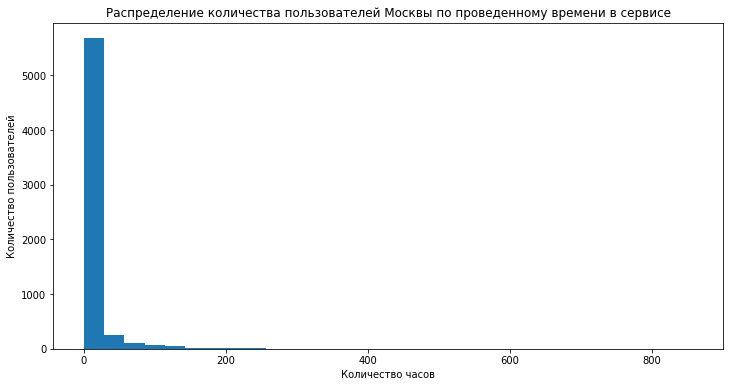

In [7]:
# Строим гистограмму распределения
moscow.plot(
    kind='hist',
    figsize=(12,6),
    title='Распределение количества пользователей Москвы по проведенному времени в сервисе',
    bins=30)
plt.xlabel('Количество часов')
plt.ylabel('Количество пользователей')
plt.show()

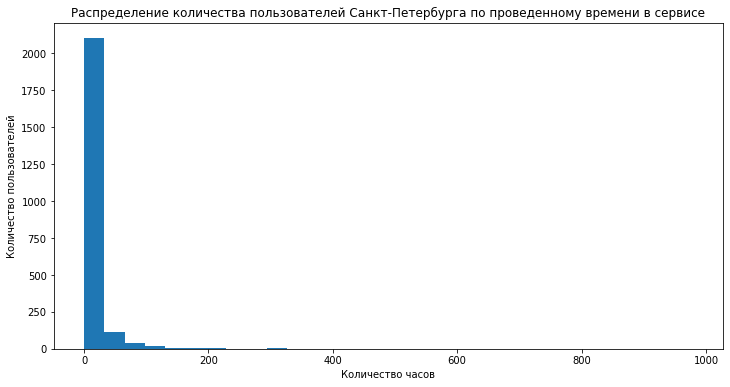

In [8]:
# Строим гистограмму распределения
spb.plot(
    kind='hist',
    figsize=(12,6),
    title='Распределение количества пользователей Санкт-Петербурга по проведенному времени в сервисе',
    bins=30)
plt.xlabel('Количество часов')
plt.ylabel('Количество пользователей')
plt.show()

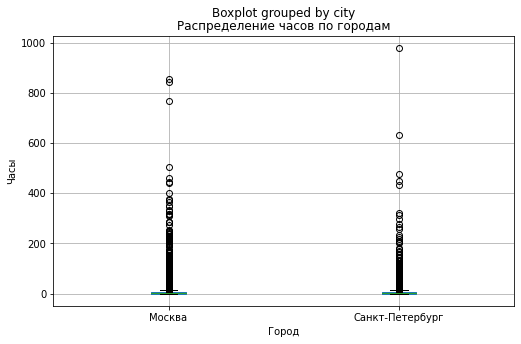

In [9]:
# Строим ящики с усами
df.boxplot(column='hours', by='city', figsize=(8, 5))
plt.title('Распределение часов по городам')
plt.xlabel('Город')
plt.ylabel('Часы')
plt.show()

Для начала были обработаны неявные дубликаты столбца `puid`, были удалены **2.7 процента** данных, далее была просмотрена статистика по двум сегментам, соотношение данных Москвы против Санкт-Петербурга оценивается примерно **3:1**, средние значения и медианы показали почти одинаковые показатели на выборках. Были построены 2 гистограммы распределения данных, после чего стало ясно, что обе выборки демонстрируют схожие распределения при разных объемах, оба распределения имеют тяжелые правые хвосты, доходящие до **800-900 часов** при большой концентрации в районе **0-50**.
В качестве статистического теста был выбран `t-тест Уэльча`, что позволит избежать неверной интерпретации из-за возможной разницы дисперсий генеральных совокупностей двух выборок. При этом данных в обеих выборках достаточно, чтобы говорить о нормальности распределения их выборочных средних. В качестве уровня значимости было взято стандратное значенте **alpha = 0.05**.

## Проверка гипотезы в Python

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [10]:
# Проверяем гипотезу
from scipy import stats

stat, p_value = stats.ttest_ind(spb, moscow, 
                                equal_var=False,
                                alternative='greater')

alpha = 0.05
print(f'pvalue={p_value}')

if p_value > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

text_interpretation = text_interpretation = 'не различается' if p_value > alpha else 'больше'

print(f'Средняя активность пользователей в Санкт-Петербурге по сравнению с Москвой {text_interpretation}.')

pvalue=0.3435708118766314
Нулевая гипотеза находит подтверждение!
Средняя активность пользователей в Санкт-Петербурге по сравнению с Москвой не различается.


После статистической оценки **(p-value = 0.34 при α = 0.05)** не удалось доказать статистическую значимость различий между выборками городов, следовательно, на данном уровне значимости нулевая гипотеза находит подтверждение.

К возможным причинам такого результата можно отнести схожее распределение данных и их статистик: средние значения составили **10.88**ч (Москва) и **11.26**ч (СПб), медианы — **0.92**ч и **0.88**ч соответственно, что демонстрирует в целом одинаковые цифры при разных объёмах выборок (6234 и 2306 пользователей).

Медианы особенно подтверждают эту картину — они почти идентичны, что говорит о том, что типичный пользователь в обоих городах ведёт себя одинаково, несмотря на небольшую разницу в средних из-за выбросов.

# Часть 2. Анализ результатов A/B-тестирования

Целью данного исследование является статистическая проверка гипотезы о том, что новый интерфейс интернет-магазина BitMotion Kit позволит увеличить конверсию зарегистрированных пользователей в покупателей как минимум на три процентных пункта.

Основные шаги проекта:
- Импортировать данные и ознакомиться с ними
- Оценить корректность проведения теста и обработать пересечения
- Отфильтровать таблицу с событиями в рамках гипотезы
- Рассчитать необходимый размер выборки и проверить достаточность данных
- Провести статистический тест и интерпретировать результаты
- Сформулировать общий вывод

In [11]:
# Считываем данные
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [12]:
# Выводим превые строки
display(participants.head())
display(events.head())

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [13]:
# Выводим информацию
display(participants.info())
display(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


None

In [14]:
# Проверяем распределение до обработки
test = participants[participants['ab_test'] == 'interface_eu_test']
test['group'].value_counts()

B    5467
A    5383
Name: group, dtype: int64

In [15]:
# Выводим общее число данных
test.shape[0]

10850

In [16]:
# Выводим количество пользователей в двух группах сразу
user_group_count = test.groupby('group')['user_id'].nunique()
intersection = user_group_count[user_group_count == 2]
print(f"Пользователей в обеих группах: {len(intersection)}")

Пользователей в обеих группах: 0


In [17]:
# Выводим пользователей, которые участвуют в нескольких тестах одновременно
other_tests_users = participants[participants['ab_test'] != 'interface_eu_test']['user_id']
contaminated = test[test['user_id'].isin(other_tests_users)]
print(f'Пользователей, участвующих сразу в двух тестах: {contaminated.shape[0]}')

Пользователей, участвующих сразу в двух тестах: 887


In [18]:
# Выводим объем данныхп после обработки
clean_users = set(test['user_id']) - set(other_tests_users)
test_clean = test[test['user_id'].isin(clean_users)]
test_clean.shape[0]

9963

In [19]:
# Выводим распределение групп после обработки
test_clean['group'].value_counts()

B    5011
A    4952
Name: group, dtype: int64

В ходе проверки корректности теста была проверена равномерность распределения теста. До обработки пересечений группа A содержит **5383** пользователя, группа B — **5467**, что соответствует соотношению примерно **50/50**. Пересечений между группами A и B не обнаружено. Однако было выявлено **887** пользователей, участвующих одновременно в другом тесте — они были исключены из анализа. После данной обработки группа A составила **4952** пользователя, группа B — **5011**, что также соотносится как **50/50**.

In [20]:
# Очищаем события, которые не связаны с изучаемым тестом
events_clear = events[events['user_id'].isin(test_clean['user_id'])]
print(f'Событий до очистки: {len(events)}')
print(f'Событий после очистки: {len(events_clear)}')
display(events_clear['event_name'].value_counts())

Событий до очистки: 787286
Событий после очистки: 73815


login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: event_name, dtype: int64

In [21]:
# Добавляем новый столбец даты регистрации
reg_dates = events_clear[events_clear['event_name'] == 'registration'].groupby('user_id')['event_dt'].min().reset_index()
reg_dates.columns = ['user_id', 'reg_dt']
events_clear = events_clear.merge(reg_dates,on='user_id',how='left')
events_clear

,user_id,event_dt,event_name,details,reg_dt
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20
...,...,...,...,...,...
73810,F80C9BDDEA02E53C,2020-12-30 10:02:43,purchase,4.49,2020-12-07 10:05:54
73811,F80C9BDDEA02E53C,2020-12-30 10:03:51,purchase,4.49,2020-12-07 10:05:54
73812,F80C9BDDEA02E53C,2020-12-30 10:03:52,product_cart,NaN,2020-12-07 10:05:54
73813,6181F3835EBE66BF,2020-12-30 12:10:39,product_cart,NaN,2020-12-07 19:53:20


In [22]:
# Добавляем столбец с разницей между событием и датой регистрации и фильтруем
# events_clear['lifetime'] = (events_clear['event_dt'] - events_clear['reg_dt']).dt.days
# events_clear = events_clear[(events_clear['lifetime'] >= 0) & (events_clear['lifetime'] <= 7)]
events_clear = events_clear.copy()
events_clear['lifetime'] = events_clear['event_dt'] - events_clear['reg_dt']
events_clear = events_clear[(events_clear['lifetime'] >= pd.Timedelta(days=0))&(events_clear['lifetime'] 
                                                                                <= pd.Timedelta(days=7))]
print(f'Событий после фильтра: {len(events_clear)}')

Событий после фильтра: 63805


In [23]:
# Проверям, достаточно ли данных для выборок
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05
power = 0.80
p = 0.30
mde = 0.03

effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print(f'Минимальный размер выборки на группу: {int(sample_size)}')

n_a = test_clean[test_clean['group'] == 'A'].shape[0]
n_b = test_clean[test_clean['group'] == 'B'].shape[0]

print(f'Фактический размер групп:')
print(f'A: {n_a}')
print(f'B: {n_b}')

if n_a >= sample_size and n_b >= sample_size:
    print('Выборка достаточна')
else:
    print('Выборка недостаточна')

Минимальный размер выборки на группу: 3761
Фактический размер групп:
A: 4952
B: 5011
Выборка достаточна


In [24]:
# Выводим события, связанные с покупками
purchases = events_clear[events_clear['event_name'] == 'purchase']
print('Событий покупки:', len(purchases))

Событий покупки: 6162


In [25]:
# Выводим количество пользователей, которые совершали покупки
purchased_users = purchases['user_id'].unique()
print('Уникальных покупателей:', len(purchased_users))

Уникальных покупателей: 2857


In [26]:
# Рассчитываем конверсии по группам
test_clean = test_clean.copy()
test_clean['purchased'] = test_clean['user_id'].isin(purchased_users).astype(int)

conversion_stats = test_clean.groupby('group').agg(
    total_users=('user_id', 'count'),
    purchased_users=('purchased', 'sum')
).reset_index()

conversion_stats['conversion_rate'] = (conversion_stats['purchased_users'] / conversion_stats['total_users'] * 100
).round(2)

display(conversion_stats)

,group,total_users,purchased_users,conversion_rate
0,A,4952,1377,27.81
1,B,5011,1480,29.54


Конверсия в тестовой группе B составила **29.54%** против **27.81%** в контрольной группе A. Таким образом, прирост составил **1.73%**. Виден рост показателя, однако он не подтвердил техническое задание о 3%. Окончательный вывод будет сделан после проверки гипотезы статистически.

Целевой метрикой является конверсия зарегистрированных пользователей в покупателей в течение 7 дней после регистрации.

Сформулированная гипотеза:
- **Нулевая гипотеза:** конверсия зарегистрированных пользователей в покупателей в тестовой группе B не превышает конверсию в контрольной группе A за первые 7 дней после регистрации.

- **Альтернативная гипотеза:** конверсия зарегистрированных пользователей в покупателей в тестовой группе B статистически значимо выше конверсии в контрольной группе A за первые 7 дней после регистрации.

In [27]:
# Проверяем гипотезу с помощью z-теста пропорции
n_a = conversion_stats[conversion_stats['group'] == 'A']['total_users'].values[0]
n_b = conversion_stats[conversion_stats['group'] == 'B']['total_users'].values[0]
m_a = conversion_stats[conversion_stats['group'] == 'A']['purchased_users'].values[0]
m_b = conversion_stats[conversion_stats['group'] == 'B']['purchased_users'].values[0]

p_a, p_b = m_a/n_a, m_b/n_b

if (p_a*n_a > 10) and ((1-p_a)*n_a > 10) and (p_b*n_b > 10) and ((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger'
)

print(f'pvalue={p_value_ztest}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

text_interpretation = 'не изменилась' if p_value_ztest > alpha else 'статистически значимо выросла'
print(f'При введении нового интерфейса, конверсия в покупку {text_interpretation}.')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.028262547212292124
Нулевая гипотеза не находит подтверждения!
При введении нового интерфейса, конверсия в покупку статистически значимо выросла.


В качестве статистического теста был выбран `z-тест для пропорций`, так как данные имеют бинарный тип и требуется сравнить две долевые метрики. Был использован односторонний вариант теста, поскольку по условиям ТЗ проверяется только увеличение конверсии. Предпосылка о достаточном количестве данных была проверена и выполняется для обеих групп. В качестве уровня значимости было взято стандартное значение alpha = 0.05.

После статистической оценки **(p-value = 0.028 при alpha = 0.05)** удалось доказать статистическую значимость роста конверсии в тестовой группе B, следовательно, на данном уровне значимости нулевая гипотеза не находит подтверждения. Однако фактический прирост составил **1.73%**, что не достигает целевого порога в **3%**, заявленного в техническом задании.